# 🏠 Real Estate Investment Advisor
## Step 1: Data Preprocessing

**Dataset:** `india_housing_prices.csv`  
**Rows:** 2,50,000 | **Columns:** 23  

---
### 📋 Preprocessing Steps:
1. Load Data
2. Drop Useless Columns
3. Handle Duplicates
4. Handle Missing Values
5. Handle Outliers (IQR Method)
6. Feature Engineering
7. Create Target Variables
8. Encode Categorical Columns
9. Scale Numerical Columns
10. Save Cleaned Data

---
## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Create models directory if not exists
os.makedirs('models', exist_ok=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 1️⃣ Load Dataset

In [2]:
df = pd.read_csv('data/india_housing_prices.csv')

print(f'✅ Dataset Loaded Successfully!')
print(f'   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Size  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

✅ Dataset Loaded Successfully!
   Shape : 250,000 rows × 23 columns
   Size  : 187.03 MB


In [3]:
# Preview the first 5 rows
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [4]:
# Check column data types
print('Column Data Types:')
print(df.dtypes)

Column Data Types:
ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object


In [5]:
# Basic statistics
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


---
## 2️⃣ Drop Useless Columns
The `ID` column is just a serial number — it has no predictive value for ML models.

In [6]:
print(f'Shape BEFORE dropping ID: {df.shape}')

df.drop(columns=['ID'], inplace=True)

print(f'Shape AFTER  dropping ID: {df.shape}')
print('✅ ID column dropped!')

Shape BEFORE dropping ID: (250000, 23)
Shape AFTER  dropping ID: (250000, 22)
✅ ID column dropped!


---
## 3️⃣ Handle Duplicates

In [7]:
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Duplicates removed! New shape: {df.shape}')
else:
    print('✅ No duplicates found. Dataset is clean!')

Duplicate rows found: 0
✅ No duplicates found. Dataset is clean!


---
## 4️⃣ Handle Missing Values

In [8]:
print('Missing Values per Column:')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values per Column:
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

Total missing values: 0


In [9]:
if missing.sum() > 0:
    # Numeric columns → fill with median
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    # Categorical columns → fill with mode
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

    print('✅ Missing values filled!')
    print(f'   Remaining missing: {df.isnull().sum().sum()}')
else:
    print('✅ No missing values to handle!')

✅ No missing values to handle!


---
## 5️⃣ Handle Outliers (IQR Method)

**IQR Formula:**
```
IQR   = Q3 - Q1
Lower = Q1 - 1.5 × IQR
Upper = Q3 + 1.5 × IQR
Remove rows outside [Lower, Upper]
```

⚠️ Note: `Price_per_SqFt` has min = 0.00 which is impossible — this will be fixed!

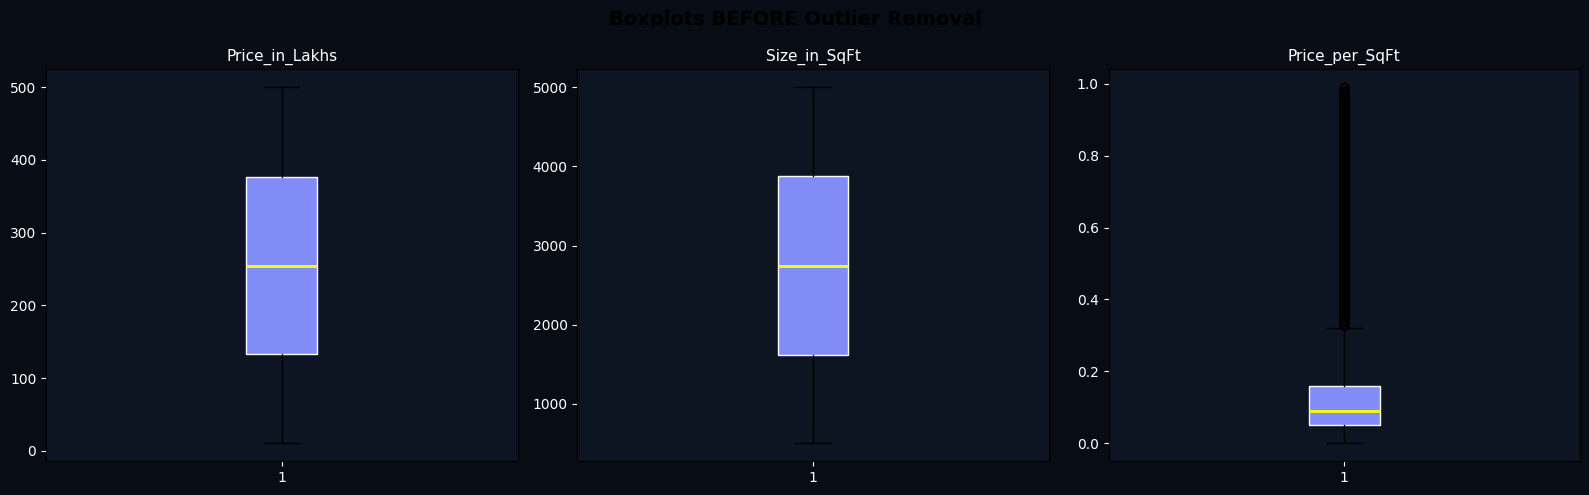

In [10]:
# Visualize outliers BEFORE removal
outlier_cols = ['Price_in_Lakhs', 'Size_in_SqFt', 'Price_per_SqFt']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplots BEFORE Outlier Removal', fontsize=14, fontweight='bold')

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#818cf8', color='white'),
               medianprops=dict(color='yellow', linewidth=2))
    ax.set_title(col, fontsize=11)
    ax.set_facecolor('#0d1422')
    fig.patch.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    ax.title.set_color('white')

plt.tight_layout()
plt.show()

In [11]:
print(f'Shape BEFORE outlier removal: {df.shape}')

for col in outlier_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = df.shape[0]
    print(f'   {col}: removed {before - after:,} outlier rows  (range: {lower:.2f} → {upper:.2f})')

print(f'\nShape AFTER  outlier removal: {df.shape}')
print('✅ Outliers removed!')

Shape BEFORE outlier removal: (250000, 22)
   Price_in_Lakhs: removed 0 outlier rows  (range: -233.94 → 743.38)
   Size_in_SqFt: removed 0 outlier rows  (range: -1753.50 → 7250.50)
   Price_per_SqFt: removed 20,020 outlier rows  (range: -0.12 → 0.33)

Shape AFTER  outlier removal: (229980, 22)
✅ Outliers removed!


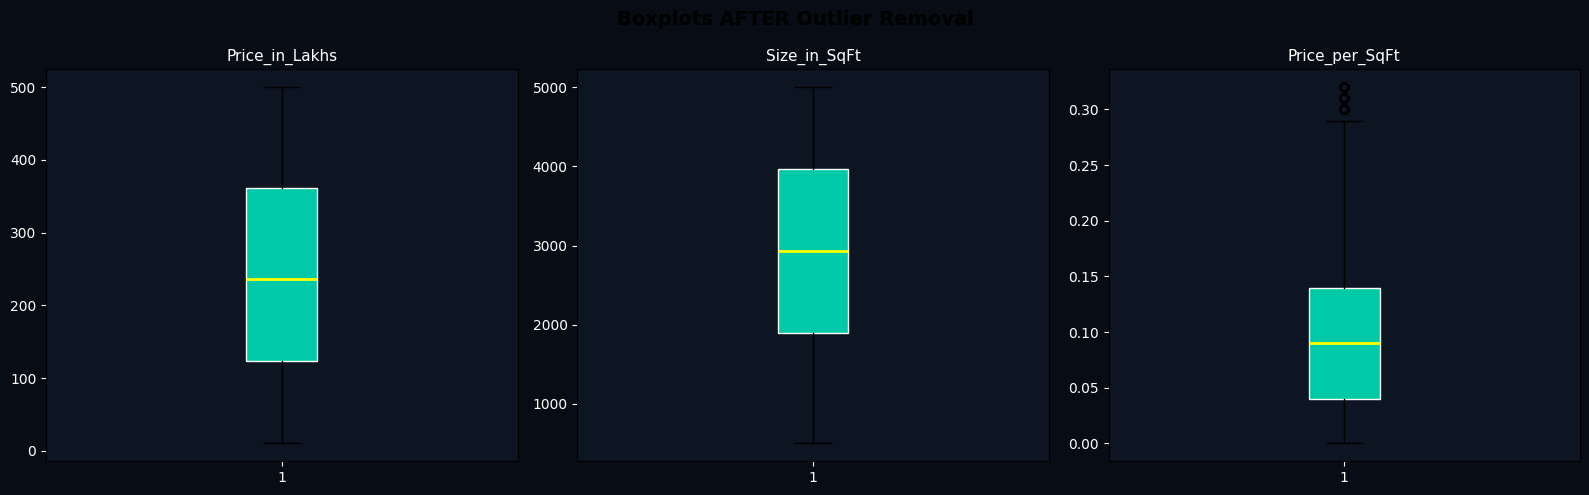

In [12]:
# Visualize AFTER removal
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplots AFTER Outlier Removal', fontsize=14, fontweight='bold')

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#00c9a7', color='white'),
               medianprops=dict(color='yellow', linewidth=2))
    ax.set_title(col, fontsize=11)
    ax.set_facecolor('#0d1422')
    fig.patch.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    ax.title.set_color('white')

plt.tight_layout()
plt.show()

---
## 6️⃣ Feature Engineering
Creating new meaningful columns from existing data to improve model performance.

In [13]:
# 1. Amenity_Count — how many amenities does the property have?
df['Amenity_Count'] = df['Amenities'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)
print('✅ Amenity_Count created')
print(f'   Sample values: {df["Amenity_Count"].value_counts().head(5).to_dict()}')

✅ Amenity_Count created
   Sample values: {4: 46273, 1: 46134, 5: 45892, 3: 45847, 2: 45834}


In [14]:
# 2. Price_per_SqFt — recalculate cleanly
df['Price_per_SqFt'] = df['Price_in_Lakhs'] / df['Size_in_SqFt']
print('✅ Price_per_SqFt refreshed')

# 3. Floor_Ratio — how high is the floor relative to the building?
df['Floor_Ratio'] = df['Floor_No'] / (df['Total_Floors'] + 1)
print('✅ Floor_Ratio created')

# 4. Amenity_Density_Score — amenities per 1000 sqft
df['Amenity_Density_Score'] = df['Amenity_Count'] / (df['Size_in_SqFt'] / 1000)
print('✅ Amenity_Density_Score created')

# 5. Is_Ready_to_Move — binary flag
df['Is_Ready_to_Move'] = df['Availability_Status'].apply(
    lambda x: 1 if x == 'Ready_to_Move' else 0
)
print('✅ Is_Ready_to_Move created')

# 6. Has_Parking — binary flag
df['Has_Parking'] = df['Parking_Space'].apply(
    lambda x: 1 if str(x).strip().lower() == 'yes' else 0
)
print('✅ Has_Parking created')

# 7. Has_Security — binary flag
df['Has_Security'] = df['Security'].apply(
    lambda x: 1 if str(x).strip().lower() == 'yes' else 0
)
print('✅ Has_Security created')

✅ Price_per_SqFt refreshed
✅ Floor_Ratio created
✅ Amenity_Density_Score created
✅ Is_Ready_to_Move created
✅ Has_Parking created
✅ Has_Security created


In [15]:
# Preview new features
new_features = ['Amenity_Count', 'Floor_Ratio', 'Amenity_Density_Score',
                'Is_Ready_to_Move', 'Has_Parking', 'Has_Security']
print('New Features Preview:')
df[new_features].head(5)

New Features Preview:


,Amenity_Count,Floor_Ratio,Amenity_Density_Score,Is_Ready_to_Move,Has_Parking,Has_Security
0,5,11.000000,1.054852,1,0,0
1,5,1.000000,2.115059,0,0,1
2,4,0.678571,1.098298,1,1,0
3,5,0.777778,1.824152,1,1,1
4,5,1.000000,1.036699,1,0,1


---
## 7️⃣ Create Target Variables

### 🎯 Target 1: `Future_Price_5Y` (Regression)
```
Future Price = Current Price × (1 + 0.08) ^ 5
```

### 🎯 Target 2: `Good_Investment` (Classification)
Score-based rule:
- Price ≤ city median price → +1
- Price per SqFt ≤ city median → +1
- BHK ≥ 3 → +1
- Ready to Move → +1
- Has Parking → +1

**Score ≥ 3 → Good Investment = 1**

In [16]:
# ── Target 1: Future_Price_5Y ──────────────────────
GROWTH_RATE = 0.08
YEARS       = 5

df['Future_Price_5Y'] = df['Price_in_Lakhs'] * ((1 + GROWTH_RATE) ** YEARS)

print('✅ Future_Price_5Y created!')
print(f'   Growth Rate : {GROWTH_RATE*100}% per year')
print(f'   Years       : {YEARS}')
print(f'\n   Sample:')
print(df[['Price_in_Lakhs', 'Future_Price_5Y']].head(5).to_string())

✅ Future_Price_5Y created!
   Growth Rate : 8.0% per year
   Years       : 5

   Sample:
   Price_in_Lakhs  Future_Price_5Y
0          489.76       719.618119
1          195.52       287.283026
2          183.79       270.047807
3          300.29       441.224528
4          182.90       268.740105


In [17]:
# ── Target 2: Good_Investment ──────────────────────
city_median_price = df.groupby('City')['Price_in_Lakhs'].transform('median')
city_median_ppsf  = df.groupby('City')['Price_per_SqFt'].transform('median')

score = (
    (df['Price_in_Lakhs']   <= city_median_price).astype(int) +
    (df['Price_per_SqFt']   <= city_median_ppsf).astype(int)  +
    (df['BHK']              >= 3).astype(int)                  +
    (df['Is_Ready_to_Move'] == 1).astype(int)                  +
    (df['Has_Parking']      == 1).astype(int)
)

df['Good_Investment'] = (score >= 3).astype(int)

good_pct = df['Good_Investment'].mean() * 100
print('✅ Good_Investment created!')
print(f'\n   Distribution:')
print(df['Good_Investment'].value_counts())
print(f'\n   {good_pct:.1f}% properties labeled as Good Investment')

✅ Good_Investment created!

   Distribution:
Good_Investment
1    122002
0    107978
Name: count, dtype: int64

   53.0% properties labeled as Good Investment


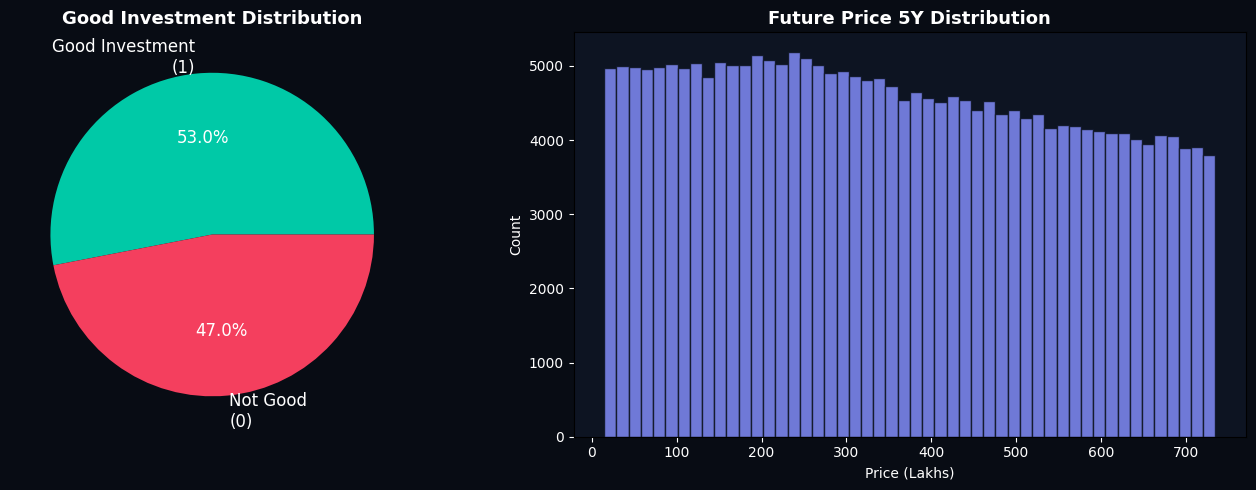

In [18]:
# Visualize target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#080c14')

# Good Investment pie chart
counts = df['Good_Investment'].value_counts()
axes[0].pie(counts, labels=['Good Investment\n(1)', 'Not Good\n(0)'],
            autopct='%1.1f%%', colors=['#00c9a7', '#f43f5e'],
            textprops={'color': 'white', 'fontsize': 12})
axes[0].set_title('Good Investment Distribution', color='white', fontsize=13, fontweight='bold')
axes[0].set_facecolor('#080c14')

# Future Price distribution
axes[1].hist(df['Future_Price_5Y'], bins=50, color='#818cf8', edgecolor='#0d1422', alpha=0.85)
axes[1].set_title('Future Price 5Y Distribution', color='white', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (Lakhs)', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].set_facecolor('#0d1422')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.show()

---
## 8️⃣ Encode Categorical Columns
ML models only understand numbers. We convert all text columns to numeric using **Label Encoding**.

In [19]:
# Drop columns already replaced by engineered features
df.drop(columns=['Amenities', 'Parking_Space', 'Security'], inplace=True)
print('✅ Dropped: Amenities, Parking_Space, Security')
print(f'   (Replaced by: Amenity_Count, Has_Parking, Has_Security)')
print(f'\n   Current shape: {df.shape}')

✅ Dropped: Amenities, Parking_Space, Security
   (Replaced by: Amenity_Count, Has_Parking, Has_Security)

   Current shape: (229980, 27)


In [20]:
# Label encode all remaining object columns
label_encoders = {}
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Columns to encode: {cat_cols}\n')

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'   ✅ {col:35s} → {len(le.classes_)} categories')

# Save encoders
joblib.dump(label_encoders, 'models/label_encoders.pkl')
print(f'\n✅ All encoders saved → models/label_encoders.pkl')

Columns to encode: ['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Facing', 'Owner_Type', 'Availability_Status']

   ✅ State                               → 20 categories
   ✅ City                                → 42 categories
   ✅ Locality                            → 500 categories
   ✅ Property_Type                       → 3 categories
   ✅ Furnished_Status                    → 3 categories
   ✅ Public_Transport_Accessibility      → 3 categories
   ✅ Facing                              → 4 categories
   ✅ Owner_Type                          → 3 categories
   ✅ Availability_Status                 → 2 categories

✅ All encoders saved → models/label_encoders.pkl


In [21]:
# Preview encoded data
print('Dataset after encoding (first 3 rows):')
df.head(3)

Dataset after encoding (first 3 rows):


,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Owner_Type,Availability_Status,Amenity_Count,Floor_Ratio,Amenity_Density_Score,Is_Ready_to_Move,Has_Parking,Has_Security,Future_Price_5Y,Good_Investment
0,15,6,483,0,1,4740,489.76,0.103325,1990,0,...,2,0,5,11.000000,1.054852,1,0,0,719.618119,0
1,11,33,434,1,3,2364,195.52,0.082707,2008,2,...,1,1,5,1.000000,2.115059,0,0,1,287.283026,1
2,13,25,75,0,2,3642,183.79,0.050464,1997,1,...,0,0,4,0.678571,1.098298,1,1,0,270.047807,1


---
## 9️⃣ Scale Numerical Features
**MinMaxScaler** brings all values to the range **[0, 1]** so no column dominates others due to large number ranges.

In [22]:
# Columns NOT to scale (targets + binary flags)
exclude_from_scaling = [
    'Good_Investment', 'Future_Price_5Y',
    'Is_Ready_to_Move', 'Has_Parking', 'Has_Security'
]

scale_cols = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if col not in exclude_from_scaling
]

print(f'Columns to scale ({len(scale_cols)}):')
for col in scale_cols:
    print(f'   → {col}')

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')
print(f'\n✅ Scaling complete!')
print(f'✅ Scaler saved → models/scaler.pkl')

Columns to scale (22):
   → State
   → City
   → Locality
   → Property_Type
   → BHK
   → Size_in_SqFt
   → Price_in_Lakhs
   → Price_per_SqFt
   → Year_Built
   → Furnished_Status
   → Floor_No
   → Total_Floors
   → Age_of_Property
   → Nearby_Schools
   → Nearby_Hospitals
   → Public_Transport_Accessibility
   → Facing
   → Owner_Type
   → Availability_Status
   → Amenity_Count
   → Floor_Ratio
   → Amenity_Density_Score

✅ Scaling complete!
✅ Scaler saved → models/scaler.pkl


In [23]:
# Verify scaling — all values should be between 0 and 1
print('Min and Max after scaling (should be 0.0 → 1.0):')
print(df[scale_cols].agg(['min', 'max']).T)

Min and Max after scaling (should be 0.0 → 1.0):
                                min  max
State                           0.0  1.0
City                            0.0  1.0
Locality                        0.0  1.0
Property_Type                   0.0  1.0
BHK                             0.0  1.0
Size_in_SqFt                    0.0  1.0
Price_in_Lakhs                  0.0  1.0
Price_per_SqFt                  0.0  1.0
Year_Built                      0.0  1.0
Furnished_Status                0.0  1.0
Floor_No                        0.0  1.0
Total_Floors                    0.0  1.0
Age_of_Property                 0.0  1.0
Nearby_Schools                  0.0  1.0
Nearby_Hospitals                0.0  1.0
Public_Transport_Accessibility  0.0  1.0
Facing                          0.0  1.0
Owner_Type                      0.0  1.0
Availability_Status             0.0  1.0
Amenity_Count                   0.0  1.0
Floor_Ratio                     0.0  1.0
Amenity_Density_Score           0.0  1.0


---
## 🔟 Final Summary & Save Cleaned Dataset

In [24]:
print('=' * 60)
print('FINAL DATASET SUMMARY')
print('=' * 60)
print(f'  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Missing Values : {df.isnull().sum().sum()}')
print(f'  Data Types     : {df.dtypes.value_counts().to_dict()}')
print(f'\n  All Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'    {i:2}. {col}')
print()
print(f'  Good_Investment  → 0: {(df["Good_Investment"]==0).sum():,}  |  1: {(df["Good_Investment"]==1).sum():,}')
print(f'  Future_Price_5Y  → min: {df["Future_Price_5Y"].min():.2f}  |  max: {df["Future_Price_5Y"].max():.2f}  Lakhs')
print('=' * 60)

FINAL DATASET SUMMARY
  Shape          : 229,980 rows × 27 columns
  Missing Values : 0
  Data Types     : {dtype('float64'): 23, dtype('int64'): 4}

  All Columns:
     1. State
     2. City
     3. Locality
     4. Property_Type
     5. BHK
     6. Size_in_SqFt
     7. Price_in_Lakhs
     8. Price_per_SqFt
     9. Year_Built
    10. Furnished_Status
    11. Floor_No
    12. Total_Floors
    13. Age_of_Property
    14. Nearby_Schools
    15. Nearby_Hospitals
    16. Public_Transport_Accessibility
    17. Facing
    18. Owner_Type
    19. Availability_Status
    20. Amenity_Count
    21. Floor_Ratio
    22. Amenity_Density_Score
    23. Is_Ready_to_Move
    24. Has_Parking
    25. Has_Security
    26. Future_Price_5Y
    27. Good_Investment

  Good_Investment  → 0: 107,978  |  1: 122,002
  Future_Price_5Y  → min: 14.69  |  max: 734.66  Lakhs


In [25]:
# Save cleaned dataset
OUTPUT_PATH = 'data/cleaned_data.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Cleaned dataset saved → {OUTPUT_PATH}')
print(f'✅ Label encoders saved  → models/label_encoders.pkl')
print(f'✅ Scaler saved          → models/scaler.pkl')
print()
print('🎉 Preprocessing Complete! Ready for EDA & Model Training.')

✅ Cleaned dataset saved → data/cleaned_data.csv
✅ Label encoders saved  → models/label_encoders.pkl
✅ Scaler saved          → models/scaler.pkl

🎉 Preprocessing Complete! Ready for EDA & Model Training.


In [26]:
# Final preview of cleaned data
print('Cleaned Dataset - First 5 Rows:')
df.head()

Cleaned Dataset - First 5 Rows:


,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Owner_Type,Availability_Status,Amenity_Count,Floor_Ratio,Amenity_Density_Score,Is_Ready_to_Move,Has_Parking,Has_Security,Future_Price_5Y,Good_Investment
0,0.789474,0.146341,0.967936,0.0,0.00,0.942222,0.979102,0.313658,0.000000,0.0,...,1.0,0.0,1.00,0.733333,0.087230,1,0,0,719.618119,0
1,0.578947,0.804878,0.869739,0.5,0.50,0.414222,0.378612,0.249821,0.545455,1.0,...,0.5,1.0,1.00,0.066667,0.195414,0,0,1,287.283026,1
2,0.684211,0.609756,0.150301,0.0,0.25,0.698222,0.354673,0.149987,0.212121,0.5,...,0.0,0.0,0.75,0.045238,0.091663,1,1,0,270.047807,1
3,0.736842,0.512195,0.653307,0.5,0.25,0.498000,0.592429,0.332948,0.030303,0.0,...,0.5,0.0,1.00,0.051852,0.165730,1,1,1,441.224528,0
4,0.736842,0.463415,0.815631,1.0,0.75,0.960667,0.352857,0.111156,0.363636,0.5,...,0.5,0.0,1.00,0.066667,0.085377,1,0,1,268.740105,1
